# COMP6001 Assignment 1
## Image Restoration and Object Detection
Name: Xiang Lu
Date: 2026-03-25

## 1. Environment Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Blur and Sharp Images

In [2]:
blur_dir = "data/blur"
sharp_dir = "data/sharp"

blur_files = os.listdir(blur_dir) if os.path.exists(blur_dir) else []
sharp_files = os.listdir(sharp_dir) if os.path.exists(sharp_dir) else []

print("Blur images:", len(blur_files))
print("Sharp images:", len(sharp_files))
print("First few blur files:", blur_files[:5])
print("First few sharp files:", sharp_files[:5])

Blur images: 10
Sharp images: 10
First few blur files: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']
First few sharp files: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']


## 3. Check Image Pair Consistency

In [3]:
blur_files = sorted(blur_files)
sharp_files = sorted(sharp_files)

print("Number of blur images:", len(blur_files))
print("Number of sharp images:", len(sharp_files))

if len(blur_files) != len(sharp_files):
    print("Warning: The number of blur and sharp images does not match.")
else:
    print("The number of blur and sharp images matches.")

matched = True
for b, s in zip(blur_files, sharp_files):
    if b != s:
        matched = False
        print("Mismatch found:", b, s)

if matched:
    print("All blur and sharp filenames are correctly matched.")

Number of blur images: 10
Number of sharp images: 10
The number of blur and sharp images matches.
All blur and sharp filenames are correctly matched.


## 4. Preview a Blur-Sharp Image Pair

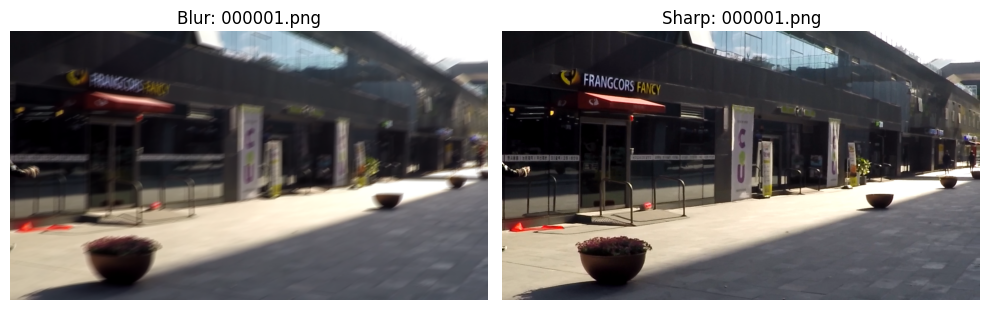

In [4]:
sample_index = 0

blur_path = os.path.join(blur_dir, blur_files[sample_index])
sharp_path = os.path.join(sharp_dir, sharp_files[sample_index])

blur_img = cv2.imread(blur_path)
sharp_img = cv2.imread(sharp_path)

blur_img_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
sharp_img_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(blur_img_rgb)
plt.title(f"Blur: {blur_files[sample_index]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharp_img_rgb)
plt.title(f"Sharp: {sharp_files[sample_index]}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Baseline Image Restoration with Unsharp Masking

In [5]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5):
    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    sharpened = cv2.addWeighted(image, 1 + amount, blurred, -amount, 0)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened

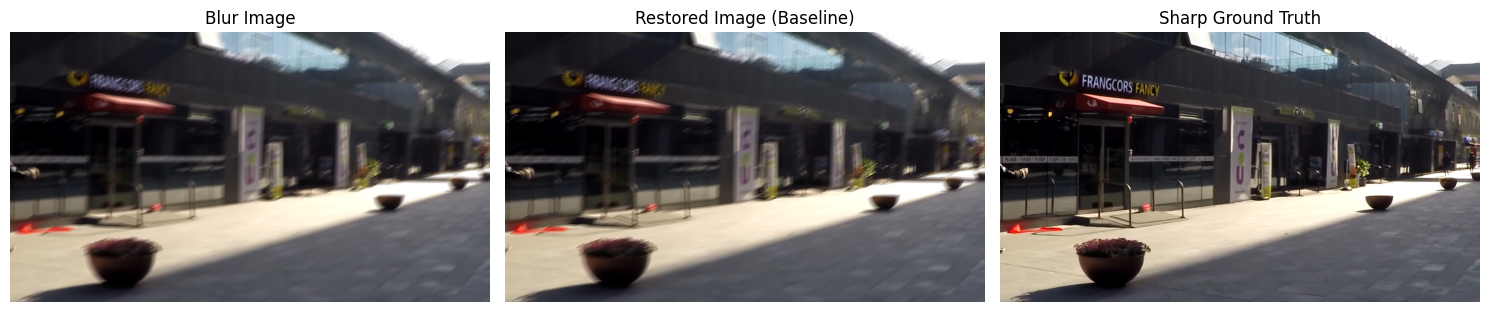

In [6]:
sample_index = 0

blur_path = os.path.join(blur_dir, blur_files[sample_index])
sharp_path = os.path.join(sharp_dir, sharp_files[sample_index])

blur_img = cv2.imread(blur_path)
sharp_img = cv2.imread(sharp_path)

restored_img = unsharp_mask(blur_img, kernel_size=(5, 5), sigma=1.0, amount=1.5)

blur_img_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
restored_img_rgb = cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB)
sharp_img_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_img_rgb)
plt.title("Blur Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored_img_rgb)
plt.title("Restored Image (Baseline)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img_rgb)
plt.title("Sharp Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

A simple sharpening-based baseline provides only limited visual improvement and cannot effectively recover details lost under motion blur.    

## 6. Quantitative Evaluation

In [7]:
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

In [8]:
# Convert images to RGB for evaluation
blur_eval = blur_img_rgb
restored_eval = restored_img_rgb
sharp_eval = sharp_img_rgb

# MSE
mse_blur = mean_squared_error(sharp_eval, blur_eval)
mse_restored = mean_squared_error(sharp_eval, restored_eval)

# PSNR
psnr_blur = peak_signal_noise_ratio(sharp_eval, blur_eval, data_range=255)
psnr_restored = peak_signal_noise_ratio(sharp_eval, restored_eval, data_range=255)

# SSIM
ssim_blur = structural_similarity(sharp_eval, blur_eval, channel_axis=2, data_range=255)
ssim_restored = structural_similarity(sharp_eval, restored_eval, channel_axis=2, data_range=255)

print("Blur vs Sharp")
print("MSE :", mse_blur)
print("PSNR:", psnr_blur)
print("SSIM:", ssim_blur)

print("\nRestored vs Sharp")
print("MSE :", mse_restored)
print("PSNR:", psnr_restored)
print("SSIM:", ssim_restored)

Blur vs Sharp
MSE : 233.85400209780093
PSNR: 24.441355541918355
SSIM: 0.8031461222795954

Restored vs Sharp
MSE : 240.99582212094907
PSNR: 24.310708471127317
SSIM: 0.7922079042536172
